# 📝 Resumen Ejecutivo: Modelo VECMX (Vector Error Correction Model con Exógenas)

Este notebook documenta la fase de *Data Preparation*, *Modeling* y *Evaluation* del modelo estadístico multivariante **VECM**. A diferencia del modelo VAR tradicional (que asume series sin relación a largo plazo), el VECM está diseñado matemáticamente para capturar y corregir las desviaciones respecto a una relación de equilibrio espacial (cointegración) existente entre múltiples sensores de tráfico.

**Evolución Metodológica:** Para esta versión definitiva, el modelo ha evolucionado a un **VECMX**, incorporando el contexto temporal (hora, día, festividades) como variables exógenas deterministas. Evaluaremos si los sensores de la autopista M-30 mantienen una relación de equilibrio a largo plazo, entrenando y comparando dos configuraciones de memoria histórica (48 lags vs 168 lags) para predecir la variable **intensidad** en horizontes de 1h, 24h y 168h, garantizando en todo momento el principio de *Zero Data Leakage*.

### 1. Importación de Librerías y Entorno
Se importan las herramientas de manipulación de datos (`pandas`), cálculo matricial (`numpy`), y las librerías estadísticas avanzadas de `statsmodels` específicas para la prueba de Johansen y la estimación del modelo de corrección de errores multivariante.

In [1]:
# ==============================================================================
# Celda 1: Importación de librerías para el modelo VECM
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías estadísticas de Statsmodels para VECM
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM, select_order
from statsmodels.tsa.vector_ar.var_model import forecast

# Métricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Utilidades
import warnings
warnings.filterwarnings("ignore")

print("✅ Librerías VECM importadas correctamente.")

✅ Librerías VECM importadas correctamente.


In [2]:
# ==============================================================================
# CELDA 2: Carga de particiones, configuración del índice y detección de nulos
# ==============================================================================

import pandas as pd

# 1. Definición de rutas
ruta_train = '../../data/processed/Split_Datasets/data_train.csv'
ruta_val   = '../../data/processed/Split_Datasets/data_val.csv'
ruta_test  = '../../data/processed/Split_Datasets/data_test.csv'

# 2. Carga de datos parseando la fecha
train_df = pd.read_csv(ruta_train, index_col='fecha', parse_dates=True)
val_df   = pd.read_csv(ruta_val,   index_col='fecha', parse_dates=True)
test_df  = pd.read_csv(ruta_test,  index_col='fecha', parse_dates=True)

# 3. Orden cronológico y frecuencia horaria
train_df = train_df.sort_index().asfreq('h')
val_df   = val_df.sort_index().asfreq('h')
test_df  = test_df.sort_index().asfreq('h')

# 4. Auditoría de valores nulos
print("🔍 AUDITORÍA DE NULOS TRAS FORZAR LA FRECUENCIA HORARIA:")
print(f"NaNs en Train: {train_df.isna().sum().sum()}")
print(f"NaNs en Val:   {val_df.isna().sum().sum()}")
print(f"NaNs en Test:  {test_df.isna().sum().sum()}")

print("\n--- RANGOS TEMPORALES ---")
print(f"Train: {train_df.index.min()} → {train_df.index.max()} | Observaciones: {len(train_df)}")
print(f"Val:   {val_df.index.min()} → {val_df.index.max()} | Observaciones: {len(val_df)}")
print(f"Test:  {test_df.index.min()} → {test_df.index.max()} | Observaciones: {len(test_df)}")

🔍 AUDITORÍA DE NULOS TRAS FORZAR LA FRECUENCIA HORARIA:
NaNs en Train: 795
NaNs en Val:   108
NaNs en Test:  21

--- RANGOS TEMPORALES ---
Train: 2024-01-01 00:00:00 → 2025-10-31 23:00:00 | Observaciones: 16080
Val:   2025-11-01 00:00:00 → 2025-12-31 23:00:00 | Observaciones: 1464
Test:  2026-01-01 00:00:00 → 2026-02-28 23:00:00 | Observaciones: 1416


In [3]:
# ==============================================================================
# CELDA 2.1: Imputación de nulos y reconstrucción de variables temporales
# ==============================================================================

# 1. Definición inicial de variables endógenas
cols_endog = [
    col for col in train_df.columns
    if 'intensidad' in col or 'ocupacion' in col or 'vmed' in col
]

# 2. Función de limpieza
def limpiar_nulos_series(df, cols_endo):
    """
    Imputa las variables endógenas mediante interpolación lineal
    y reconstruye las variables exógenas de calendario desde el índice temporal.
    """
    
    # Imputación de variables físicas
    df[cols_endo] = df[cols_endo].interpolate(method='linear', limit_direction='both')
    df[cols_endo] = df[cols_endo].bfill().ffill()
    
    # Reconstrucción de variables de calendario desde el índice
    df['hora']       = df.index.hour
    df['dia_semana'] = df.index.dayofweek
    df['mes']        = df.index.month
    df['es_finde']   = (df['dia_semana'] >= 5).astype(int)
    
    return df

# 3. Aplicar limpieza a Train, Val y Test
train_df = limpiar_nulos_series(train_df, cols_endog)
val_df   = limpiar_nulos_series(val_df, cols_endog)
test_df  = limpiar_nulos_series(test_df, cols_endog)

# 4. Verificación final
nulos_finales = (
    train_df.isna().sum().sum()
    + val_df.isna().sum().sum()
    + test_df.isna().sum().sum()
)

if nulos_finales == 0:
    print("✅ LIMPIEZA COMPLETADA: 0 valores nulos en todos los datasets.")
    print("Las series temporales son continuas y están listas para el modelo VECM.")
else:
    print(f"⚠️ Aún quedan {nulos_finales} valores nulos.")

✅ LIMPIEZA COMPLETADA: 0 valores nulos en todos los datasets.
Las series temporales son continuas y están listas para el modelo VECM.


In [4]:
# ==============================================================================
# CELDA 2.2: Evaluación Temporal Estricta y Variables Endógenas/Exógenas
# ==============================================================================

# IMPORTANTE:
# Se conserva TODO el periodo de Test para la evaluación rolling.
# La fecha 2026-02-02 únicamente se utilizará después en las visualizaciones.
fecha_inicio_visualizacion = '2026-02-02 00:00:00'

# 1. Variables endógenas
cols_endog = [
    col for col in train_df.columns
    if 'intensidad' in col or 'ocupacion' in col or 'vmed' in col
]

# 2. Variables exógenas de calendario
cols_exog = ['hora', 'dia_semana', 'mes', 'es_finde']

# 3. Validación de estructura
print("-" * 60)
print("ESTADO FINAL DE LOS DATASETS:")
print(f"Train: {train_df.shape} | Inicio: {train_df.index.min()} | Fin: {train_df.index.max()}")
print(f"Val:   {val_df.shape} | Inicio: {val_df.index.min()} | Fin: {val_df.index.max()}")
print(f"Test:  {test_df.shape} | Inicio: {test_df.index.min()} | Fin: {test_df.index.max()}")
print("-" * 60)
print(f"Endógenas ({len(cols_endog)} variables):")
print(cols_endog)
print("-" * 60)
print(f"Exógenas ({len(cols_exog)} variables):")
print(cols_exog)
print("-" * 60)

------------------------------------------------------------
ESTADO FINAL DE LOS DATASETS:
Train: (16080, 16) | Inicio: 2024-01-01 00:00:00 | Fin: 2025-10-31 23:00:00
Val:   (1464, 16) | Inicio: 2025-11-01 00:00:00 | Fin: 2025-12-31 23:00:00
Test:  (1416, 16) | Inicio: 2026-01-01 00:00:00 | Fin: 2026-02-28 23:00:00
------------------------------------------------------------
Endógenas (12 variables):
['intensidad_3820', 'intensidad_6642', 'intensidad_6676', 'intensidad_6782', 'ocupacion_3820', 'ocupacion_6642', 'ocupacion_6676', 'ocupacion_6782', 'vmed_3820', 'vmed_6642', 'vmed_6676', 'vmed_6782']
------------------------------------------------------------
Exógenas (4 variables):
['hora', 'dia_semana', 'mes', 'es_finde']
------------------------------------------------------------


In [5]:
# ==============================================================================
# CELDA 3: Selección del Lag Óptimo (48h vs 168h)
# ==============================================================================

from statsmodels.tsa.vector_ar.vecm import select_order

print("Iniciando búsqueda de rezagos óptimos. Esto puede tardar unos minutos por la matriz de 168h...")

# En la selección de lags de statsmodels para VECM usamos solo la matriz endógena.
# Las variables exógenas se incorporan posteriormente en el entrenamiento final.
data_train_endog = train_df[cols_endog]

# 1. Búsqueda con tope de 48 horas
print("\n--- Analizando tope máximo de 48 horas ---")
lag_order_48 = select_order(
    data_train_endog,
    maxlags=48,
    deterministic='co'
)

print(lag_order_48.summary())
opt_lag_48 = lag_order_48.aic

# 2. Búsqueda con tope de 168 horas
print("\n--- Analizando tope máximo de 168 horas ---")
lag_order_168 = select_order(
    data_train_endog,
    maxlags=168,
    deterministic='co'
)

print(lag_order_168.summary())
opt_lag_168 = lag_order_168.aic

print("\n" + "=" * 55)
print(f"✅ Lag óptimo seleccionado (Top 48h):  {opt_lag_48} rezagos")
print(f"✅ Lag óptimo seleccionado (Top 168h): {opt_lag_168} rezagos")
print("=" * 55)

Iniciando búsqueda de rezagos óptimos. Esto puede tardar unos minutos por la matriz de 168h...

--- Analizando tope máximo de 48 horas ---
 VECM Order Selection (* highlights the minimums) 
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        70.33       70.41   3.513e+30       70.36
1        69.18       69.33   1.108e+30       69.23
2        68.87       69.09   8.148e+29       68.95
3        68.63       68.92   6.381e+29       68.72
4        68.39       68.74   5.018e+29       68.51
5        68.26       68.69   4.432e+29       68.40
6        68.16       68.65   3.976e+29       68.32
7        68.04       68.60   3.548e+29       68.23
8        67.94       68.57   3.201e+29       68.15
9        67.82       68.53   2.855e+29       68.06
10       67.67       68.44   2.450e+29       67.93
11       67.59       68.43   2.270e+29       67.87
12       67.52       68.42   2.097e+29       67.82
13       67.43       68.41   1.921e+29       

In [6]:
# ==============================================================================
# CELDA 4: Test de Cointegración de Johansen
# ==============================================================================

from statsmodels.tsa.vector_ar.vecm import coint_johansen
import pandas as pd

print("⏳ Ejecutando Test de Johansen...")

# Parámetros del Test de Johansen:
# det_order = 0: constante en las series.
# k_ar_diff = 47: equivalente a una estructura de 48 rezagos.
johansen_test = coint_johansen(
    train_df[cols_endog],
    det_order=0,
    k_ar_diff=47
)

# Extracción de resultados
traces = johansen_test.lr1
cv_95  = johansen_test.cvt[:, 1]

# Tabla de resultados
johansen_results = pd.DataFrame({
    'Variable (r)': [f"r <= {i}" for i in range(len(cols_endog))],
    'Estadístico Traza': traces,
    'Valor Crítico (95%)': cv_95,
    'Cointegración Significativa': traces > cv_95
})

print("\n✅ RESULTADOS DEL TEST DE JOHANSEN (Nivel de confianza: 95%)")
print("=" * 75)
print(johansen_results.to_string(index=False))
print("=" * 75)

# Rango de cointegración detectado
rango_coint = int(johansen_results['Cointegración Significativa'].sum())

print(f"\n💡 Rango de cointegración detectado (r): {rango_coint}")
print("Este es el número de relaciones de equilibrio a largo plazo entre las variables.")

# Para mantener coherencia con el modelo original:
# En tu implementación original se utiliza rango completo.
r = len(cols_endog)

print(f"\n✅ Rango utilizado en el entrenamiento VECM: r = {r}")
print("Nota: Se mantiene rango completo para conservar la configuración original del modelo.")

⏳ Ejecutando Test de Johansen...

✅ RESULTADOS DEL TEST DE JOHANSEN (Nivel de confianza: 95%)
Variable (r)  Estadístico Traza  Valor Crítico (95%)  Cointegración Significativa
      r <= 0        2209.982986             334.9795                         True
      r <= 1        1837.129374             285.1402                         True
      r <= 2        1495.569792             239.2468                         True
      r <= 3        1184.966845             197.3772                         True
      r <= 4         899.154657             159.5290                         True
      r <= 5         695.305336             125.6185                         True
      r <= 6         530.323924              95.7542                         True
      r <= 7         378.791893              69.8189                         True
      r <= 8         250.647602              47.8545                         True
      r <= 9         146.554130              29.7961                         True
    

In [7]:
# ==============================================================================
# CELDA 5: Entrenamiento de los Modelos VECMX (48h y 168h) con Variables Exógenas
# ==============================================================================
from statsmodels.tsa.vector_ar.vecm import VECM

print("Iniciando entrenamiento de los modelos VECMX... (Esto tomará tiempo, especialmente el de 168h)")

# 1. Preparación de matrices de entrenamiento
endog_train = train_df[cols_endog]
exog_train  = train_df[cols_exog]

# Rango de cointegración detectado por Johansen
# En tu caso original se estaba usando rango completo: r = 12
r = 12

print(f"Rango de cointegración utilizado: r = {r}")

# 2. Entrenamiento del Modelo VECM(48)
print("\n⏳ Entrenando VECMX(48 lags)...")

vecm_model_48 = VECM(
    endog=endog_train,
    exog=exog_train,
    k_ar_diff=47,
    coint_rank=r,
    deterministic='co'
)

vecm_fitted_48 = vecm_model_48.fit()
print("✅ VECMX(48) entrenado con éxito.")

# 3. Entrenamiento del Modelo VECM(168)
print("\n⏳ Entrenando VECMX(168 lags)...")

vecm_model_168 = VECM(
    endog=endog_train,
    exog=exog_train,
    k_ar_diff=167,
    coint_rank=r,
    deterministic='co'
)

vecm_fitted_168 = vecm_model_168.fit()
print("✅ VECMX(168) entrenado con éxito.")

Iniciando entrenamiento de los modelos VECMX... (Esto tomará tiempo, especialmente el de 168h)
Rango de cointegración utilizado: r = 12

⏳ Entrenando VECMX(48 lags)...
✅ VECMX(48) entrenado con éxito.

⏳ Entrenando VECMX(168 lags)...
✅ VECMX(168) entrenado con éxito.


In [8]:
# ==============================================================================
# CELDA 6: Predicciones Rolling sobre TODO el periodo Test - VECM Optimizado
# ==============================================================================

import numpy as np
import pandas as pd
from statsmodels.tsa.vector_ar.var_model import forecast

print("Generando predicciones rolling sobre todo el periodo Test sin reentrenar en cada ventana...")

# ----------------------------------------------------------------------
# 1. Histórico base disponible antes del Test
# ----------------------------------------------------------------------

historico_base_endog = pd.concat([
    train_df[cols_endog],
    val_df[cols_endog]
])

historico_base_exog = pd.concat([
    train_df[cols_exog],
    val_df[cols_exog]
])

# Arrays para acelerar el proceso
endog_hist_base_arr = historico_base_endog.values
test_endog_arr      = test_df[cols_endog].values
test_exog_arr       = test_df[cols_exog].values

# Histórico completo de endógenas:
# train + val + test
# En cada ventana se usa solo hasta el punto i del Test.
endog_total_arr = np.vstack([
    endog_hist_base_arr,
    test_endog_arr
])

n_base = len(endog_hist_base_arr)
n_test = len(test_df)

# ----------------------------------------------------------------------
# 2. Función auxiliar: Forecast VECM con historia móvil
# ----------------------------------------------------------------------

def forecast_vecm_con_historia(modelo_fitted, historia_y, exog_futuro, steps):
    """
    Genera predicciones con un VECM ya ajustado, pero usando una historia móvil
    personalizada, equivalente a pasar y=historia en VAR.forecast().

    Esto evita reentrenar el modelo en cada ventana rolling.
    """

    historia_y = np.asarray(historia_y)
    exog_futuro = np.asarray(exog_futuro)

    # Últimas observaciones necesarias según el orden VAR equivalente del VECM
    last_observations = historia_y[-modelo_fitted.k_ar:]

    # Componentes determinísticos externos: deterministic='co'
    exog_partes = []
    trend_partes = []

    # Constante fuera de la relación de cointegración
    if modelo_fitted.const.size > 0:
        exog_partes.append(np.ones(steps))
        trend_partes.append(modelo_fitted.const.T)

    # Variables exógenas futuras
    if modelo_fitted.exog is not None:
        exog_partes.append(exog_futuro[:steps])
        trend_partes.append(modelo_fitted.exog_coefs.T)

    exog = np.column_stack(exog_partes) if len(exog_partes) > 0 else None
    trend_coefs = np.vstack(trend_partes) if len(trend_partes) > 0 else None

    pred = forecast(
        y=last_observations,
        coefs=modelo_fitted.var_rep,
        trend_coefs=trend_coefs,
        steps=steps,
        exog=exog
    )

    return pred

# ----------------------------------------------------------------------
# 3. Función Rolling Multi-Horizonte
# ----------------------------------------------------------------------

def rolling_vecm_optimizado(modelo_fitted, nombre_modelo):
    """
    Evalúa el VECM sobre todo el Test con rolling forecast:

    - H=1h: una predicción por cada hora del Test.
    - H=24h: una ventana cada 24 horas.
    - H=168h: una ventana cada 168 horas.

    No reentrena el VECM en cada ventana.
    Usa los coeficientes ya ajustados y actualiza únicamente la historia conocida.
    """

    reales_1h, preds_1h = [], []
    reales_24h, preds_24h = [], []
    reales_168h, preds_168h = [], []

    print(f"\n--- FORECASTING ROLLING SOBRE TEST ({nombre_modelo}) ---")

    # -----------------------------
    # Horizonte 1h
    # -----------------------------
    for i in range(n_test):

        historia = endog_total_arr[:n_base + i]
        exog_fut = test_exog_arr[i:i+1]

        pred = forecast_vecm_con_historia(
            modelo_fitted=modelo_fitted,
            historia_y=historia,
            exog_futuro=exog_fut,
            steps=1
        )

        reales_1h.append(test_endog_arr[i])
        preds_1h.append(pred[0])

    # -----------------------------
    # Horizonte 24h
    # -----------------------------
    for i in range(0, n_test - 23, 24):

        historia = endog_total_arr[:n_base + i]
        exog_fut = test_exog_arr[i:i+24]

        pred = forecast_vecm_con_historia(
            modelo_fitted=modelo_fitted,
            historia_y=historia,
            exog_futuro=exog_fut,
            steps=24
        )

        reales_24h.append(test_endog_arr[i:i+24])
        preds_24h.append(pred)

    # -----------------------------
    # Horizonte 168h
    # -----------------------------
    for i in range(0, n_test - 167, 168):

        historia = endog_total_arr[:n_base + i]
        exog_fut = test_exog_arr[i:i+168]

        pred = forecast_vecm_con_historia(
            modelo_fitted=modelo_fitted,
            historia_y=historia,
            exog_futuro=exog_fut,
            steps=168
        )

        reales_168h.append(test_endog_arr[i:i+168])
        preds_168h.append(pred)

    reales_1h   = np.array(reales_1h)
    preds_1h    = np.array(preds_1h)

    reales_24h  = np.vstack(reales_24h)
    preds_24h   = np.vstack(preds_24h)

    reales_168h = np.vstack(reales_168h)
    preds_168h  = np.vstack(preds_168h)

    print(f"✅ Rolling 1h   completado: {len(reales_1h)} puntos evaluados")
    print(f"✅ Rolling 24h  completado: {len(reales_24h)} puntos evaluados")
    print(f"✅ Rolling 168h completado: {len(reales_168h)} puntos evaluados")

    return reales_1h, preds_1h, reales_24h, preds_24h, reales_168h, preds_168h

# ----------------------------------------------------------------------
# 4. Ejecutar Rolling Forecast VECM-48 y VECM-168
# ----------------------------------------------------------------------

(
    reales_1h_48,
    preds_1h_48,
    reales_24h_48,
    preds_24h_48,
    reales_168h_48,
    preds_168h_48
) = rolling_vecm_optimizado(vecm_fitted_48, "VECM-48h")

(
    reales_1h_168,
    preds_1h_168,
    reales_24h_168,
    preds_24h_168,
    reales_168h_168,
    preds_168h_168
) = rolling_vecm_optimizado(vecm_fitted_168, "VECM-168h")

# ----------------------------------------------------------------------
# 5. Predicción específica para visualización:
#    Semana del 2 al 8 de febrero de 2026
# ----------------------------------------------------------------------

semana_inicio = pd.Timestamp('2026-02-02 00:00:00')
semana_fin    = pd.Timestamp('2026-02-08 23:00:00')

pos_inicio_visual = test_df.index.get_loc(semana_inicio)
pos_fin_visual    = pos_inicio_visual + 168

historia_visual = endog_total_arr[:n_base + pos_inicio_visual]
exog_visual     = test_exog_arr[pos_inicio_visual:pos_fin_visual]

y_real_168h = test_df.iloc[pos_inicio_visual:pos_fin_visual]

print("\nGenerando predicciones específicas para visualización semanal...")

pred_48_raw = forecast_vecm_con_historia(
    modelo_fitted=vecm_fitted_48,
    historia_y=historia_visual,
    exog_futuro=exog_visual,
    steps=168
)

pred_48_df = pd.DataFrame(
    pred_48_raw,
    index=y_real_168h.index,
    columns=cols_endog
)

pred_48_1h  = pred_48_df.iloc[:1]
pred_48_24h = pred_48_df.iloc[:24]

pred_168_raw = forecast_vecm_con_historia(
    modelo_fitted=vecm_fitted_168,
    historia_y=historia_visual,
    exog_futuro=exog_visual,
    steps=168
)

pred_168_df = pd.DataFrame(
    pred_168_raw,
    index=y_real_168h.index,
    columns=cols_endog
)

pred_168_1h  = pred_168_df.iloc[:1]
pred_168_24h = pred_168_df.iloc[:24]

print("-" * 60)
print("✅ Predicciones rolling completadas con éxito.")
print(f"Dimensiones rolling 1h VECM-48:   {preds_1h_48.shape}")
print(f"Dimensiones rolling 24h VECM-48:  {preds_24h_48.shape}")
print(f"Dimensiones rolling 168h VECM-48: {preds_168h_48.shape}")
print(f"Dimensiones visualización semanal: {pred_48_df.shape} (Debe ser 168, 12)")
print("-" * 60)

Generando predicciones rolling sobre todo el periodo Test sin reentrenar en cada ventana...

--- FORECASTING ROLLING SOBRE TEST (VECM-48h) ---
✅ Rolling 1h   completado: 1416 puntos evaluados
✅ Rolling 24h  completado: 1416 puntos evaluados
✅ Rolling 168h completado: 1344 puntos evaluados

--- FORECASTING ROLLING SOBRE TEST (VECM-168h) ---
✅ Rolling 1h   completado: 1416 puntos evaluados
✅ Rolling 24h  completado: 1416 puntos evaluados
✅ Rolling 168h completado: 1344 puntos evaluados

Generando predicciones específicas para visualización semanal...
------------------------------------------------------------
✅ Predicciones rolling completadas con éxito.
Dimensiones rolling 1h VECM-48:   (1416, 12)
Dimensiones rolling 24h VECM-48:  (1416, 12)
Dimensiones rolling 168h VECM-48: (1344, 12)
Dimensiones visualización semanal: (168, 12) (Debe ser 168, 12)
------------------------------------------------------------


In [9]:
# --- 6.3 TABLA RESUMEN DE MÉTRICAS (TEST COMPLETO) - VECM ---

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Estructura: resultados_test[(n_lags, horizonte)][sensor] = {"RMSE": , "MAE": , "R²": }
resultados_test = {}

sensores = ["Sensor 3820", "Sensor 6642", "Sensor 6676", "Sensor 6782"]
lags_a_evaluar = [48, 168]
horizontes_a_evaluar = [1, 24, 168]

# Columnas de intensidad
cols_intensidad = [c for c in cols_endog if 'intensidad' in c]

# Índices de intensidad dentro de cols_endog
idx_intensidad = [cols_endog.index(col) for col in cols_intensidad]

print("Calculando métricas por sensor en Test completo (solo Intensidad)...")

def calcular_metricas_rolling(reales_arr, preds_arr):
    resultado = {}

    for idx, col in zip(idx_intensidad, cols_intensidad):

        sensor_name = f"Sensor {col.split('_')[1]}"

        y_true = reales_arr[:, idx]
        y_pred = preds_arr[:, idx]

        resultado[sensor_name] = {
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAE": mean_absolute_error(y_true, y_pred),
            "R²": r2_score(y_true, y_pred)
        }

    return resultado

# VECM-48
resultados_test[(48, 1)]   = calcular_metricas_rolling(reales_1h_48,   preds_1h_48)
resultados_test[(48, 24)]  = calcular_metricas_rolling(reales_24h_48,  preds_24h_48)
resultados_test[(48, 168)] = calcular_metricas_rolling(reales_168h_48, preds_168h_48)

# VECM-168
resultados_test[(168, 1)]   = calcular_metricas_rolling(reales_1h_168,   preds_1h_168)
resultados_test[(168, 24)]  = calcular_metricas_rolling(reales_24h_168,  preds_24h_168)
resultados_test[(168, 168)] = calcular_metricas_rolling(reales_168h_168, preds_168h_168)

# === TABLA RESUMEN ===
horizontes_nombres = {1: '1 HORA', 24: '24 HORAS', 168: '168 HORAS'}

for horizonte in horizontes_a_evaluar:
    nombre_h = horizontes_nombres[horizonte]

    print(f"\n{'='*74}")
    print(f"  HORIZONTE: {nombre_h} — VECM-48h vs VECM-168h")
    print(f"{'='*74}")
    print(f"  {'Sensor':<14} {'VECM-48':>28}   {'VECM-168':>28}")
    print(f"  {'':14} {'RMSE':>8} {'MAE':>9} {'R²':>9}   {'RMSE':>8} {'MAE':>9} {'R²':>9}")
    print(f"  {'-'*70}")

    rmse_48, mae_48, r2_48 = [], [], []
    rmse_168, mae_168, r2_168 = [], [], []

    for sensor in sensores:
        m48  = resultados_test[(48, horizonte)][sensor]
        m168 = resultados_test[(168, horizonte)][sensor]

        print(
            f"  {sensor:<14} "
            f"{m48['RMSE']:>8.2f} {m48['MAE']:>9.2f} {m48['R²']:>9.4f}   "
            f"{m168['RMSE']:>8.2f} {m168['MAE']:>9.2f} {m168['R²']:>9.4f}"
        )

        rmse_48.append(m48['RMSE'])
        mae_48.append(m48['MAE'])
        r2_48.append(m48['R²'])

        rmse_168.append(m168['RMSE'])
        mae_168.append(m168['MAE'])
        r2_168.append(m168['R²'])

    print(f"  {'-'*70}")
    print(
        f"  {'PROMEDIO':<14} "
        f"{np.mean(rmse_48):>8.2f} {np.mean(mae_48):>9.2f} {np.mean(r2_48):>9.4f}   "
        f"{np.mean(rmse_168):>8.2f} {np.mean(mae_168):>9.2f} {np.mean(r2_168):>9.4f}"
    )

print("\n✅ Métricas por sensor calculadas y tablas impresas.")

Calculando métricas por sensor en Test completo (solo Intensidad)...

  HORIZONTE: 1 HORA — VECM-48h vs VECM-168h
  Sensor                              VECM-48                       VECM-168
                     RMSE       MAE        R²       RMSE       MAE        R²
  ----------------------------------------------------------------------
  Sensor 3820      420.32    288.78    0.9494     399.66    273.24    0.9543
  Sensor 6642      455.64    316.74    0.9543     418.47    289.86    0.9615
  Sensor 6676      431.08    287.50    0.9448     413.40    268.30    0.9492
  Sensor 6782      400.66    283.85    0.9480     371.19    262.07    0.9554
  ----------------------------------------------------------------------
  PROMEDIO         426.92    294.22    0.9491     400.68    273.37    0.9551

  HORIZONTE: 24 HORAS — VECM-48h vs VECM-168h
  Sensor                              VECM-48                       VECM-168
                     RMSE       MAE        R²       RMSE       MAE        R²


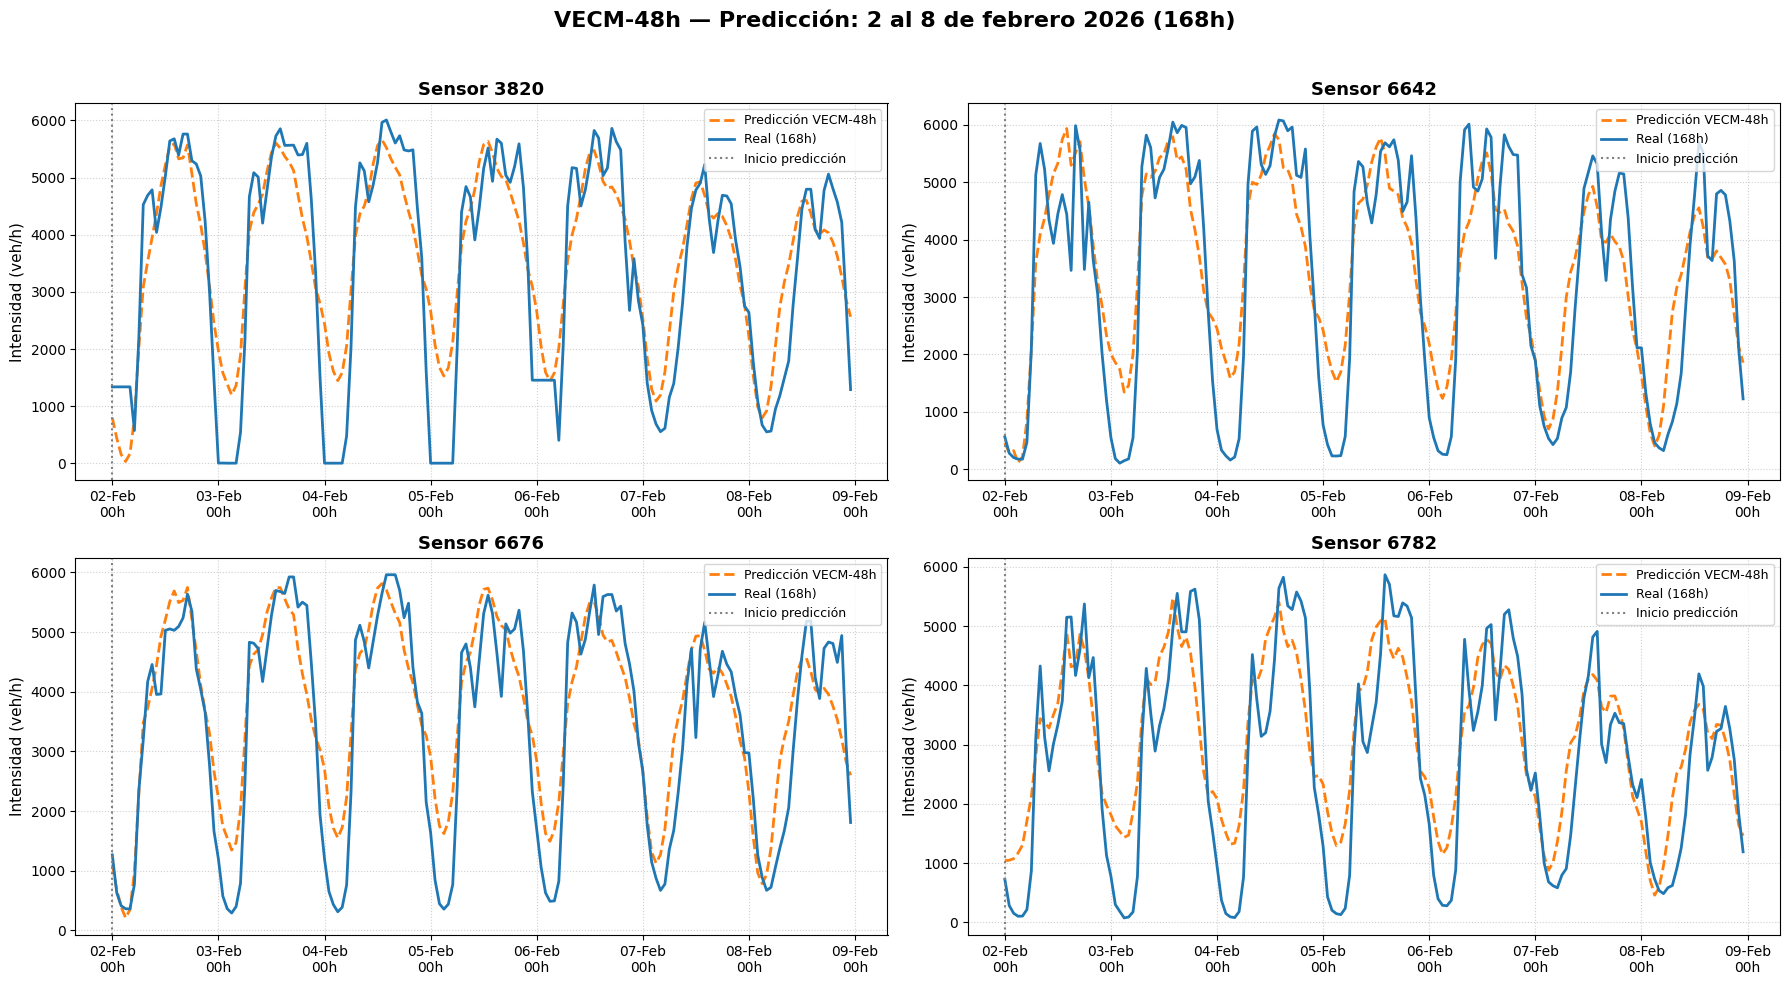

✅ Gráfica guardada en: ../../data/processed/figures/grafica_vecm48_168h.png


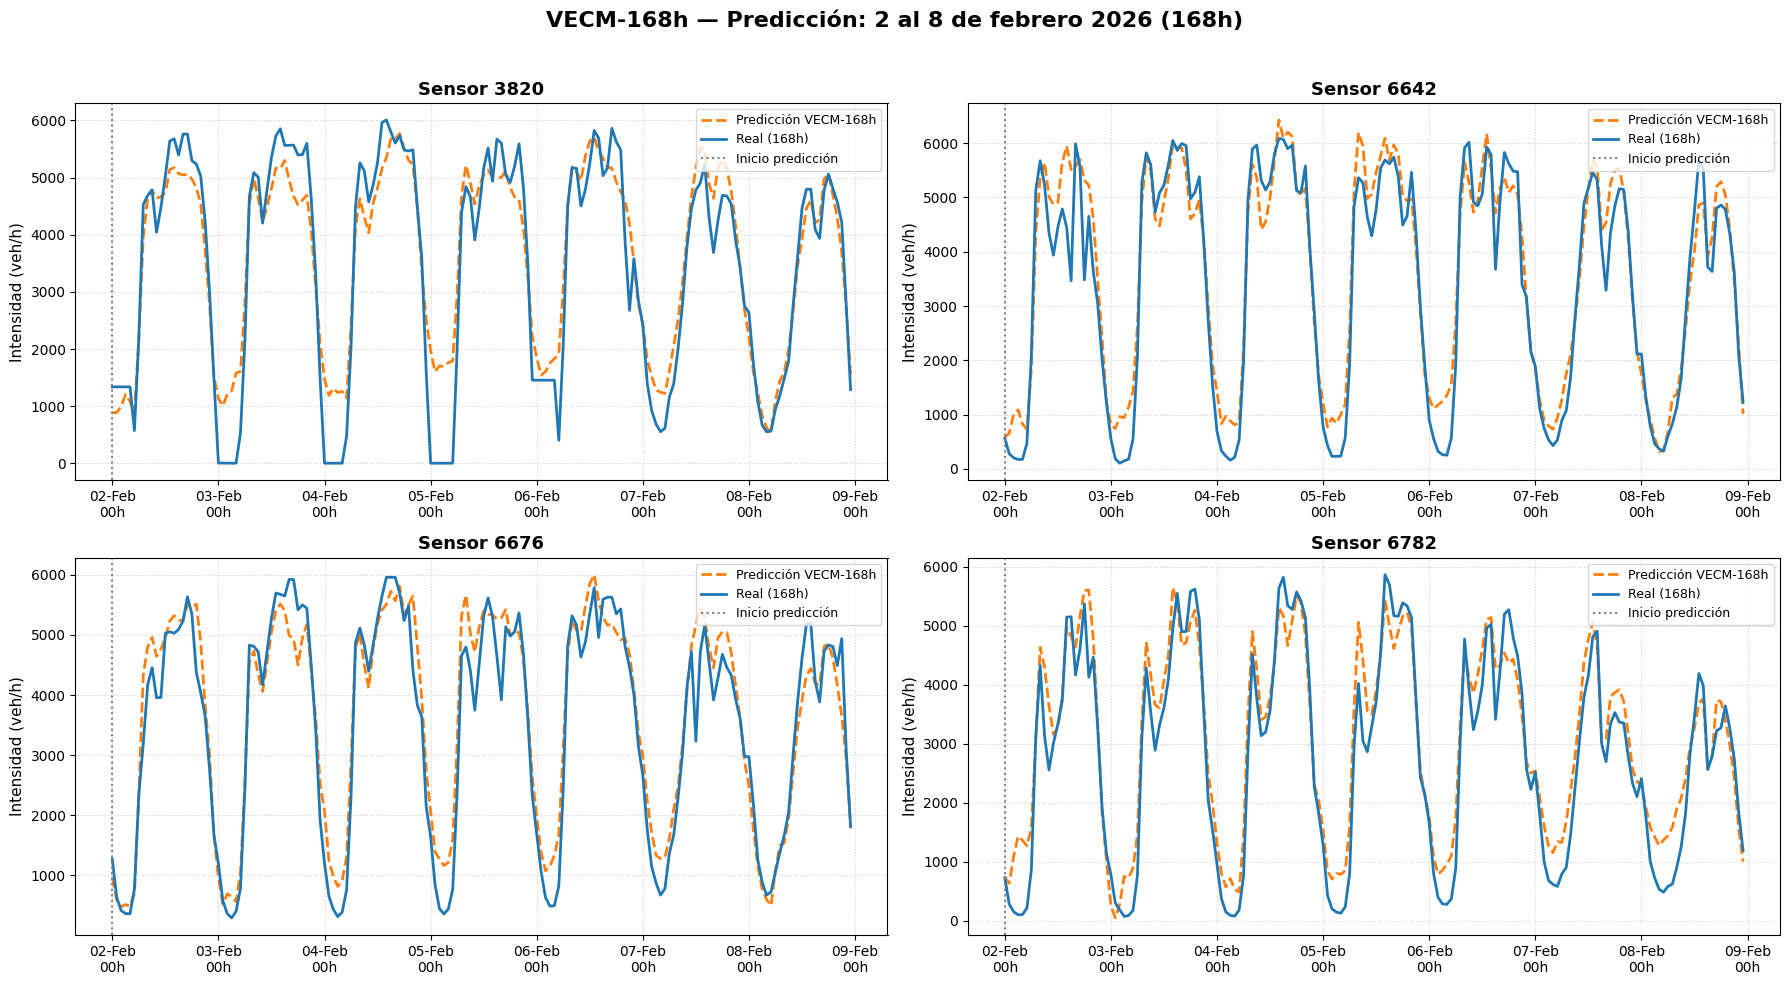

✅ Gráfica guardada en: ../../data/processed/figures/grafica_vecm168_168h.png


In [10]:
# --- 6.4 GRÁFICAS SEMANA 2-8 FEBRERO 2026 (horizonte 168h) - VECM ---

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# === Ruta de guardado ===
ruta_figuras = '../../data/processed/figures'
os.makedirs(ruta_figuras, exist_ok=True)

semana_inicio = pd.Timestamp('2026-02-02 00:00:00')
semana_fin    = pd.Timestamp('2026-02-08 23:00:00')

cols_intensidad = [c for c in cols_endog if 'intensidad' in c]
sensor_ids      = ['3820', '6642', '6676', '6782']

for n_lags, pred_df in [(48, pred_48_df), (168, pred_168_df)]:

    nombre_modelo = f'VECM-{n_lags}h'

    real_semana = y_real_168h.loc[semana_inicio:semana_fin, cols_intensidad]
    pred_semana = pred_df.loc[semana_inicio:semana_fin, cols_intensidad]

    # === Figura 2x2 ===
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))
    fig.suptitle(
        f'{nombre_modelo} — Predicción: 2 al 8 de febrero 2026 (168h)',
        fontsize=16, fontweight='bold', y=0.98
    )
    axes = axes.flatten()

    for i, col in enumerate(cols_intensidad):
        ax        = axes[i]
        sensor_id = sensor_ids[i]

        ax.plot(
            pred_semana.index, pred_semana[col],
            color='#ff7f0e', linewidth=2, linestyle='--',
            label=f'Predicción {nombre_modelo}'
        )
        ax.plot(
            real_semana.index, real_semana[col],
            color='#1f77b4', linewidth=2, label='Real (168h)'
        )
        ax.axvline(
            x=semana_inicio, color='grey', linestyle=':',
            linewidth=1.5, label='Inicio predicción'
        )
        ax.set_title(f'Sensor {sensor_id}', fontsize=13, fontweight='bold')
        ax.set_ylabel('Intensidad (veh/h)', fontsize=11)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b\n%Hh'))
        ax.xaxis.set_major_locator(mdates.DayLocator())
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper right', fontsize=9)
        ax.tick_params(axis='x', rotation=0)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # === Guardar gráfica ===
    ruta_grafica = f'{ruta_figuras}/grafica_vecm{n_lags}_168h.png'
    plt.savefig(ruta_grafica, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Gráfica guardada en: {ruta_grafica}")

In [11]:
# --- 6.5 EXCEL COMPARATIVO VECM-48h vs VECM-168h ---

import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import os

ruta_carpeta = '../../data/processed/models/4.VECM'
os.makedirs(ruta_carpeta, exist_ok=True)
ruta_excel = f'{ruta_carpeta}/comparativa_VECM48_vs_VECM168.xlsx'

horizontes_nombres = {1: '1_HORA', 24: '24_HORAS', 168: '168_HORAS'}
horizontes_titulos = {1: '1 HORA', 24: '24 HORAS', 168: '168 HORAS'}

# Estilos
def estilo_titulo(ws, fila, texto):
    ws.merge_cells(start_row=fila, start_column=1, end_row=fila, end_column=7)
    c = ws.cell(row=fila, column=1, value=texto)
    c.font      = Font(bold=True, color='FFFFFF', size=12)
    c.fill      = PatternFill('solid', fgColor='2F4F8F')
    c.alignment = Alignment(horizontal='center', vertical='center')

def aplicar_borde(cell):
    thin = Side(style='thin')
    cell.border = Border(left=thin, right=thin, top=thin, bottom=thin)

wb = openpyxl.Workbook()
wb.remove(wb.active)

for horizonte in horizontes_a_evaluar:
    nombre_hoja = horizontes_nombres[horizonte]
    titulo_hoja = horizontes_titulos[horizonte]
    ws = wb.create_sheet(title=nombre_hoja)

    anchos = [16, 12, 12, 12, 12, 12, 12]
    for i, ancho in enumerate(anchos, 1):
        ws.column_dimensions[get_column_letter(i)].width = ancho

    # Título
    estilo_titulo(ws, 1, f'HORIZONTE: {titulo_hoja} — VECM-48h vs VECM-168h')
    ws.row_dimensions[1].height = 22

    # Cabecera modelos
    ws.merge_cells(start_row=2, start_column=2, end_row=2, end_column=4)
    ws.merge_cells(start_row=2, start_column=5, end_row=2, end_column=7)

    for col, texto, color in [(2, 'VECM-48h', '2E86AB'), (5, 'VECM-168h', 'A23B72')]:
        c = ws.cell(row=2, column=col, value=texto)
        c.font      = Font(bold=True, color='FFFFFF', size=10)
        c.fill      = PatternFill('solid', fgColor=color)
        c.alignment = Alignment(horizontal='center', vertical='center')

    # Subcabecera métricas
    ws.cell(row=3, column=1, value='Sensor').font = Font(bold=True, color='FFFFFF', size=10)
    ws.cell(row=3, column=1).fill                 = PatternFill('solid', fgColor='4472C4')
    ws.cell(row=3, column=1).alignment            = Alignment(horizontal='center')

    for col, metrica in enumerate(['RMSE', 'MAE', 'R²', 'RMSE', 'MAE', 'R²'], 2):
        c = ws.cell(row=3, column=col, value=metrica)
        c.font      = Font(bold=True, color='FFFFFF', size=10)
        c.fill      = PatternFill('solid', fgColor='4472C4')
        c.alignment = Alignment(horizontal='center')

    # Datos por sensor
    colores_fila = ['FCE4D6', 'E2EFDA', 'FCE4D6', 'E2EFDA']

    for idx, sensor in enumerate(sensores):
        fila  = 4 + idx
        color = colores_fila[idx]

        m48  = resultados_test[(48, horizonte)][sensor]
        m168 = resultados_test[(168, horizonte)][sensor]

        valores = [
            sensor,
            round(m48['RMSE'], 2), round(m48['MAE'], 2), round(m48['R²'], 4),
            round(m168['RMSE'], 2), round(m168['MAE'], 2), round(m168['R²'], 4)
        ]

        for col, val in enumerate(valores, 1):
            c = ws.cell(row=fila, column=col, value=val)
            c.fill      = PatternFill('solid', fgColor=color)
            c.font      = Font(size=10)
            c.alignment = Alignment(horizontal='center')
            aplicar_borde(c)

    # Fila PROMEDIO
    fila_prom = 8
    ws.cell(row=fila_prom, column=1, value='PROMEDIO')

    promedios = [
        np.mean([resultados_test[(48, horizonte)][s]['RMSE'] for s in sensores]),
        np.mean([resultados_test[(48, horizonte)][s]['MAE']  for s in sensores]),
        np.mean([resultados_test[(48, horizonte)][s]['R²']   for s in sensores]),
        np.mean([resultados_test[(168, horizonte)][s]['RMSE'] for s in sensores]),
        np.mean([resultados_test[(168, horizonte)][s]['MAE']  for s in sensores]),
        np.mean([resultados_test[(168, horizonte)][s]['R²']   for s in sensores]),
    ]

    for col, val in enumerate([None] + promedios, 1):
        c = ws.cell(row=fila_prom, column=col)

        if col > 1:
            c.value = round(val, 4) if col in [4, 7] else round(val, 2)

        c.font      = Font(bold=True, size=10)
        c.fill      = PatternFill('solid', fgColor='D9E1F2')
        c.alignment = Alignment(horizontal='center')
        aplicar_borde(c)

wb.save(ruta_excel)
print(f"✅ Excel guardado en: {ruta_excel}")

✅ Excel guardado en: ../../data/processed/models/4.VECM/comparativa_VECM48_vs_VECM168.xlsx
